# Programa o Script para reducción de dimensionalidad
# Realizado por : Rolando Ortiz Herbas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from decimal import Decimal, getcontext
import csv

In [2]:
# Cargar dataset
# Reemplaza 'dataset.csv' por el nombre de tu archivo
# Asegúrate de que el archivo tenga solo las columnas numéricas necesarias para PCA
getcontext().prec = 30
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/Clientes_Dos_Mil_numeros.csv"
data = pd.read_csv(ruta , header=0)
# data = pd.read_csv('dataset.csv')

In [3]:
data.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV,Y
0,47.0,35,302783,6.0,0.0,20150417,20150417,20180221,20200417,5046,...,1.0,0.0,2.0,1.0,0.0,9,1,1,36,1
1,38.0,38,211366,5.0,0.0,20150220,20150220,20180208,20200220,7044,...,0.0,0.0,2.0,3.0,0.0,9,1,1,40,1
2,13.0,50,323640,1.0,0.0,20150220,20160115,20190218,20200220,0,...,1.0,0.0,1.0,3.0,47.0,8,1,1,50,1
3,59.0,60,377036,1.0,0.0,20150417,20150717,20200305,20200417,12566,...,1.0,0.0,1.0,3.0,13.0,9,0,1,61,1
4,97.0,45,392349,6.0,0.0,20150417,20150417,20181226,20200417,6539,...,0.0,1.0,2.0,3.0,0.0,9,0,1,46,1


In [4]:
X1 = data.iloc[:, :-1]
# Y = np.array(data["Y"])
y = data["Y"]

In [5]:
X1.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,CostoAdmin,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV
0,47.0,35,302783,6.0,0.0,20150417,20150417,20180221,20200417,5046,...,17468,1.0,0.0,2.0,1.0,0.0,9,1,1,36
1,38.0,38,211366,5.0,0.0,20150220,20150220,20180208,20200220,7044,...,19040,0.0,0.0,2.0,3.0,0.0,9,1,1,40
2,13.0,50,323640,1.0,0.0,20150220,20160115,20190218,20200220,0,...,24485,1.0,0.0,1.0,3.0,47.0,8,1,1,50
3,59.0,60,377036,1.0,0.0,20150417,20150717,20200305,20200417,12566,...,28599,1.0,0.0,1.0,3.0,13.0,9,0,1,61
4,97.0,45,392349,6.0,0.0,20150417,20150417,20181226,20200417,6539,...,22024,0.0,1.0,2.0,3.0,0.0,9,0,1,46


In [6]:
#scaler = StandardScaler()
#data_scaled = scaler.fit_transform(X1)

# Paso 1: Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(X1)

In [10]:

# Paso 2–5: PCA (reducimos a 1 dimensión)
n_components=27
pca = PCA(n_components)
X_pca = pca.fit_transform(X_std)
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Componentes principales:", pca.components_)

Varianza explicada: [2.54381659e-01 1.45309687e-01 1.01205083e-01 5.99638569e-02
 5.78879544e-02 5.20509891e-02 4.16038502e-02 3.82369264e-02
 3.72626864e-02 3.58432077e-02 3.49482382e-02 3.27880289e-02
 2.88705417e-02 2.71182007e-02 1.91759125e-02 1.36187417e-02
 5.89753581e-03 4.87247358e-03 2.69410918e-03 2.18304022e-03
 1.75296413e-03 1.22213716e-03 7.07248826e-04 2.74149282e-04
 9.16261355e-05 3.91516300e-05 1.14539358e-17]
Componentes principales: [[ 1.38654604e-03  3.58612523e-01  2.94508620e-01 -7.07735290e-02
  -1.58286138e-01 -2.57874494e-01 -2.14829724e-01  3.37665613e-02
  -2.57874494e-01  1.48370354e-02  2.90787099e-01  2.68821803e-01
   1.02911929e-01  5.21037523e-02 -4.10581128e-02 -3.54235855e-02
   3.48535950e-01  3.60559944e-01  2.70859159e-02  3.90812790e-02
  -8.49295270e-02  2.31965989e-02  9.53483464e-02  1.28025723e-02
   4.51408328e-02 -5.96592669e-03  3.58044456e-01]
 [-4.08683830e-03  8.72951352e-02  1.17515590e-01 -2.70005065e-02
   1.87388108e-01  3.37115827

In [ ]:
# Paso 6: Regresión logística con los datos transformados
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Exactitud:", accuracy_score(y_test, y_pred))

Exactitud: 1.0


In [12]:
# Crear un DataFrame con los resultados
columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=columns)

In [13]:
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nResultados del PCA:")
print(df_pca)

Varianza explicada por cada componente:
[2.54381659e-01 1.45309687e-01 1.01205083e-01 5.99638569e-02
 5.78879544e-02 5.20509891e-02 4.16038502e-02 3.82369264e-02
 3.72626864e-02 3.58432077e-02 3.49482382e-02 3.27880289e-02
 2.88705417e-02 2.71182007e-02 1.91759125e-02 1.36187417e-02
 5.89753581e-03 4.87247358e-03 2.69410918e-03 2.18304022e-03
 1.75296413e-03 1.22213716e-03 7.07248826e-04 2.74149282e-04
 9.16261355e-05 3.91516300e-05 1.14539358e-17]

Resultados del PCA:
           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0     0.085569 -3.705398  2.427960 -1.371650 -0.922134 -1.632122 -1.703357   
1     0.080109 -3.856955  2.158675 -0.349628 -0.994316 -1.174705 -0.616766   
2     2.580049 -1.337888 -0.763909 -1.180211 -0.431601 -1.400349 -1.860741   
3     3.706099 -2.075186  1.776740 -0.406550 -1.694717  0.172662 -0.660180   
4     2.272102 -2.924972  3.726790  2.705101  0.520984  0.536134  0.524437   
...        ...       ...       ...       ...       ...    

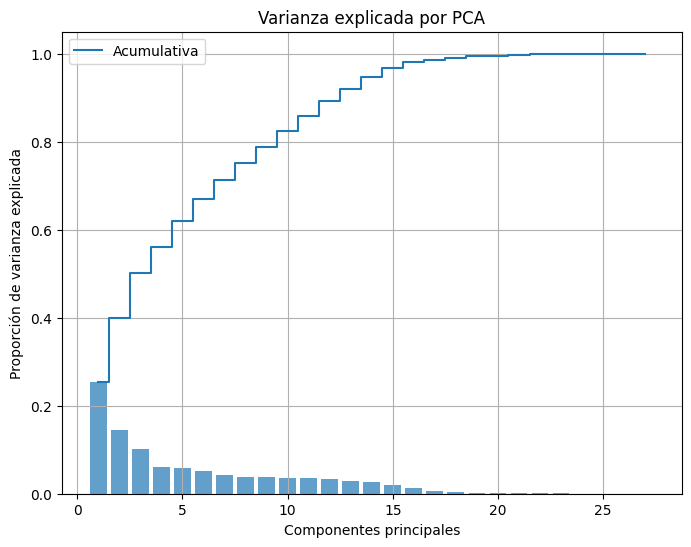

In [14]:
# Gráfico de varianza explicada
plt.figure(figsize=(8, 6))
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.step(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Acumulativa')
plt.ylabel('Proporción de varianza explicada')
plt.xlabel('Componentes principales')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.grid(True)
plt.show()

# De la grafica anterior vemos que con 12 componentes (PCA1...PCA12) explicamos el 90% de los datos

In [16]:
# Paso 2–5: PCA (reducimos a 1 dimensión)
n_components=12
pca = PCA(n_components)
X_pca = pca.fit_transform(X_std)
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Componentes principales:", pca.components_)

Varianza explicada: [0.25438166 0.14530969 0.10120508 0.05996386 0.05788795 0.05205099
 0.04160385 0.03823693 0.03726269 0.03584321 0.03494824 0.03278803]
Componentes principales: [[ 1.38654604e-03  3.58612523e-01  2.94508620e-01 -7.07735290e-02
  -1.58286138e-01 -2.57874494e-01 -2.14829724e-01  3.37665613e-02
  -2.57874494e-01  1.48370354e-02  2.90787099e-01  2.68821803e-01
   1.02911929e-01  5.21037523e-02 -4.10581128e-02 -3.54235855e-02
   3.48535950e-01  3.60559944e-01  2.70859159e-02  3.90812790e-02
  -8.49295270e-02  2.31965989e-02  9.53483464e-02  1.28025723e-02
   4.51408328e-02 -5.96592669e-03  3.58044456e-01]
 [-4.08683830e-03  8.72951352e-02  1.17515590e-01 -2.70005065e-02
   1.87388108e-01  3.37115827e-01  3.81453739e-01  4.50821054e-01
   3.37115827e-01 -2.51758770e-01  1.13520303e-01  1.06811548e-01
   3.63404381e-01 -1.52976083e-03 -1.88795168e-01 -2.19019698e-01
   1.45266430e-01  1.73255779e-02 -1.10281764e-04  1.11823810e-02
  -4.80534620e-02  1.19592321e-04  1.440760

In [ ]:
# Paso 6: Regresión logística con los datos transformados
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Exactitud:", accuracy_score(y_test, y_pred))

Exactitud: 0.9966666666666667


In [18]:
# Crear un DataFrame con los resultados
columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=columns)

In [19]:
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nResultados del PCA:")
print(df_pca)

Varianza explicada por cada componente:
[0.25438166 0.14530969 0.10120508 0.05996386 0.05788795 0.05205099
 0.04160385 0.03823693 0.03726269 0.03584321 0.03494824 0.03278803]

Resultados del PCA:
           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0     0.085569 -3.705398  2.427960 -1.371650 -0.922134 -1.632122 -1.703357   
1     0.080109 -3.856955  2.158675 -0.349628 -0.994316 -1.174705 -0.616766   
2     2.580049 -1.337888 -0.763909 -1.180211 -0.431601 -1.400349 -1.860741   
3     3.706099 -2.075186  1.776740 -0.406550 -1.694717  0.172662 -0.660180   
4     2.272102 -2.924972  3.726790  2.705101  0.520984  0.536134  0.524437   
...        ...       ...       ...       ...       ...       ...       ...   
1995  0.577556  1.790352 -0.044922 -0.089139 -0.053562 -0.391269 -0.826320   
1996 -0.635987 -2.450529  0.810045 -0.528474 -1.075083  0.798395 -0.094607   
1997 -1.496012 -1.721213 -2.293196  0.211327  0.478305  0.791944 -0.292177   
1998 -1.889894  2.001280

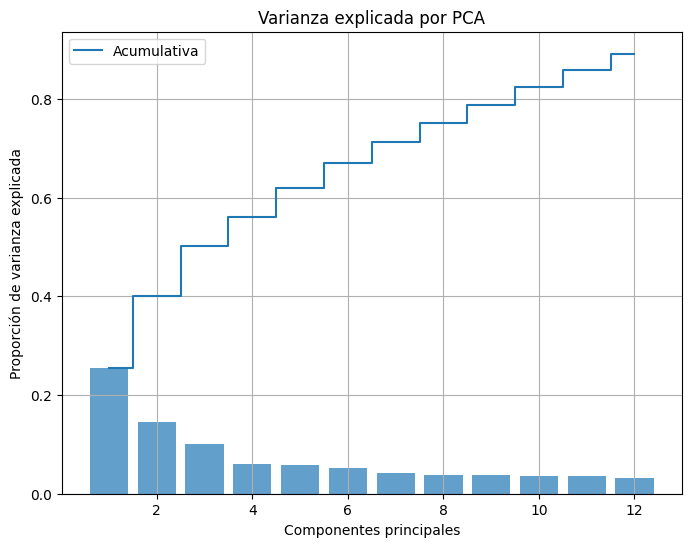

In [20]:
# Gráfico de varianza explicada
plt.figure(figsize=(8, 6))
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.step(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Acumulativa')
plt.ylabel('Proporción de varianza explicada')
plt.xlabel('Componentes principales')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# df_pca.to_csv('output.csv', index=False)
data = pd.concat([df_pca, y], axis=1)

data.to_csv('C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/OUTPUT_PCA.csv', index=False, quoting=csv.QUOTE_NONNUMERIC)